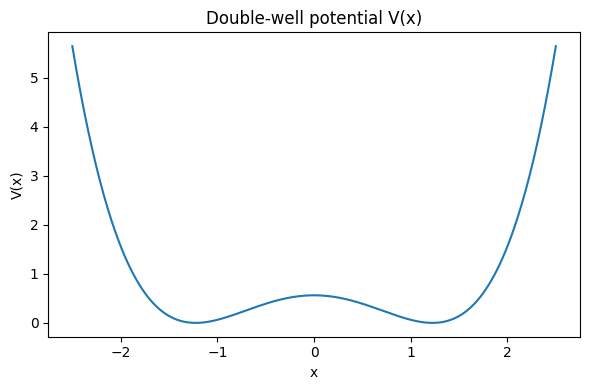

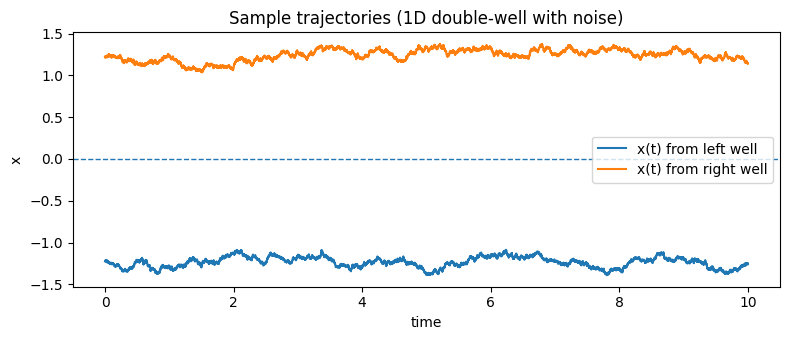

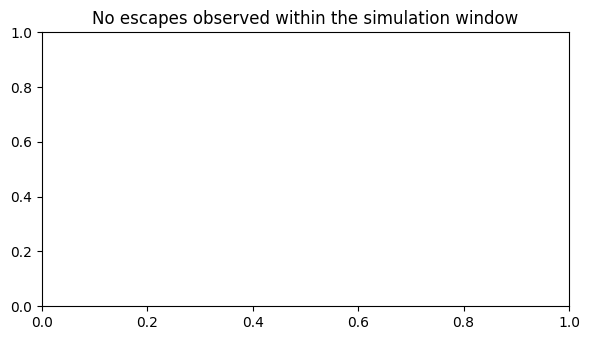

ModuleNotFoundError: No module named 'caas_jupyter_tools'

In [3]:
# Two-attractor toy models: simulations + visualizations
#
# This notebook runs:
# 1) 1D double-well SDE with Euler–Maruyama, shows potential landscape and sample trajectories,
#    and estimates escape-time statistics between wells.
# 2) 2D Wilson–Cowan-like bistable system, shows nullclines + flow field + trajectories,
#    and estimates basin fractions from random initial conditions.
#
# Notes for plotting:
# - Using matplotlib (no seaborn)
# - One chart per figure
# - No explicit color styling is set

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Callable, Dict
import math
import pandas as pd

# -----------------------------
# 1) 1D double-well SDE
# -----------------------------

@dataclass
class DoubleWellParams:
    a: float = 1.5     # well separation/depth
    b: float = 0.0     # tilt (bias)
    sigma: float = 0.15 # noise amplitude
    dt: float = 1e-3
    T: float = 10.0

def V_double_well(x, a=1.0, b=0.0):
    # V(x) = 1/4 (x^2 - a)^2 - b x
    return 0.25*(x**2 - a)**2 - b*x

def dVdx_double_well(x, a=1.0, b=0.0):
    # derivative dV/dx = x(x^2 - a) - b
    return x*(x**2 - a) - b

def simulate_double_well(params: DoubleWellParams, x0: float, seed: int = 0):
    rng = np.random.default_rng(seed)
    n = int(params.T/params.dt)
    x = np.empty(n)
    x[0] = x0
    for i in range(1, n):
        x_prev = x[i-1]
        x[i] = x_prev - dVdx_double_well(x_prev, params.a, params.b)*params.dt \
               + params.sigma*np.sqrt(params.dt)*rng.normal()
    t = np.linspace(0.0, params.T, n)
    return t, x

def estimate_escape_time(params: DoubleWellParams, x0: float, target_region: Tuple[float,float], seed: int = 0, tmax: float = None):
    # First passage time to interval target_region
    rng = np.random.default_rng(seed)
    dt = params.dt
    n = int((tmax if tmax is not None else params.T)/dt)
    x = x0
    for i in range(1, n+1):
        x = x - dVdx_double_well(x, params.a, params.b)*dt + params.sigma*np.sqrt(dt)*rng.normal()
        if target_region[0] <= x <= target_region[1]:
            return i*dt
    return np.nan  # not reached

# Set parameters and run
dw_params = DoubleWellParams(a=1.5, b=0.0, sigma=0.15, dt=1e-3, T=10.0)

# Plot potential and sample trajectories from each well
xs = np.linspace(-2.5, 2.5, 500)
V = V_double_well(xs, a=dw_params.a, b=dw_params.b)

plt.figure(figsize=(6,4))
plt.plot(xs, V)
plt.title("Double-well potential V(x)")
plt.xlabel("x")
plt.ylabel("V(x)")
plt.tight_layout()
plt.show()

# Sample trajectories from both wells
t1, x1 = simulate_double_well(dw_params, x0=-math.sqrt(dw_params.a), seed=1)
t2, x2 = simulate_double_well(dw_params, x0=+math.sqrt(dw_params.a), seed=2)

plt.figure(figsize=(8,3.5))
plt.plot(t1, x1, label="x(t) from left well")
plt.plot(t2, x2, label="x(t) from right well")
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.title("Sample trajectories (1D double-well with noise)")
plt.xlabel("time")
plt.ylabel("x")
plt.legend()
plt.tight_layout()
plt.show()

# Estimate escape times (left -> right well) by many trials
# Define the "arrival" region for right well around +sqrt(a)
right_center = math.sqrt(dw_params.a)
arrival = (right_center-0.2, right_center+0.2)

n_trials = 100
esc_times = []
for k in range(n_trials):
    et = estimate_escape_time(dw_params, x0=-right_center, target_region=arrival, seed=1000+k, tmax=dw_params.T)
    esc_times.append(et)

esc_times = np.array(esc_times, dtype=float)
plt.figure(figsize=(6,3.5))
valid = esc_times[~np.isnan(esc_times)]
if valid.size > 0:
    plt.hist(valid, bins=15)
    plt.title("Escape time distribution (left → right well)")
    plt.xlabel("first-passage time")
    plt.ylabel("count")
else:
    plt.title("No escapes observed within the simulation window")
plt.tight_layout()
plt.show()

# Summarize escape stats
escape_summary = {
    "trials": n_trials,
    "observed_escapes": int(np.isfinite(esc_times).sum()),
    "mean_escape_time": float(np.nanmean(esc_times)) if np.isfinite(esc_times).any() else np.nan,
    "median_escape_time": float(np.nanmedian(esc_times)) if np.isfinite(esc_times).any() else np.nan,
    "min_escape_time": float(np.nanmin(esc_times)) if np.isfinite(esc_times).any() else np.nan,
    "max_escape_time": float(np.nanmax(esc_times)) if np.isfinite(esc_times).any() else np.nan,
}
escape_df = pd.DataFrame([escape_summary])
import caas_jupyter_tools as cj
cj.display_dataframe_to_user("Double-well escape-time summary", escape_df)

# -----------------------------
# 2) 2D Wilson–Cowan-like bistable system
# -----------------------------

@dataclass
class WCParams:
    wxx: float = 2.0
    wxy: float = 3.0
    wyx: float = 3.0
    wyy: float = 2.0
    Ix: float = 0.5
    Iy: float = 0.5
    tau: float = 0.02
    beta: float = 6.0
    theta: float = 0.3
    sigma: float = 0.01
    dt: float = 1e-3
    T: float = 5.0

def phi(z, beta=4.0, theta=0.0):
    return 1.0/(1.0 + np.exp(-beta*(z - theta)))

def wc_step(x, y, p: WCParams):
    dx = (-x + phi(p.wxx*x - p.wxy*y + p.Ix, p.beta, p.theta))/p.tau
    dy = (-y + phi(p.wyy*y - p.wyx*x + p.Iy, p.beta, p.theta))/p.tau
    return dx, dy

def simulate_wc(p: WCParams, x0: float, y0: float, seed: int = 0):
    rng = np.random.default_rng(seed)
    n = int(p.T/p.dt)
    xs = np.empty(n); ys = np.empty(n)
    xs[0], ys[0] = x0, y0
    for i in range(1, n):
        dx, dy = wc_step(xs[i-1], ys[i-1], p)
        xs[i]   = xs[i-1] + p.dt*(dx) + p.sigma*np.sqrt(p.dt)*rng.normal()
        ys[i]   = ys[i-1] + p.dt*(dy) + p.sigma*np.sqrt(p.dt)*rng.normal()
    t = np.linspace(0.0, p.T, n)
    return t, xs, ys

wc_params = WCParams()

# Plot nullclines and flow field
grid_n = 25
xgrid = np.linspace(0.0, 1.0, grid_n)
ygrid = np.linspace(0.0, 1.0, grid_n)
X, Y = np.meshgrid(xgrid, ygrid)

DX = np.zeros_like(X)
DY = np.zeros_like(Y)
for i in range(grid_n):
    for j in range(grid_n):
        dx, dy = wc_step(X[i,j], Y[i,j], wc_params)
        DX[i,j] = dx
        DY[i,j] = dy

# Compute nullclines numerically: solve y-nullcline for dy=0 and x-nullcline for dx=0 by scanning
# We'll plot as contours at level 0
plt.figure(figsize=(5.2,5.2))
plt.streamplot(X, Y, DX, DY, density=1.2, linewidth=1)
CS1 = plt.contour(X, Y, DX, levels=[0.0], linestyles='--')
CS2 = plt.contour(X, Y, DY, levels=[0.0], linestyles=':')
plt.title("Wilson–Cowan flow with nullclines (dx=0 dashed, dy=0 dotted)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Simulate a few trajectories from different initial conditions
inits = [(0.05,0.05), (0.9,0.1), (0.1,0.9), (0.6,0.6)]
plt.figure(figsize=(5.6,5.2))
plt.streamplot(X, Y, DX, DY, density=1.0, linewidth=0.8)
for k, (x0,y0) in enumerate(inits):
    t, xs, ys = simulate_wc(wc_params, x0, y0, seed=10+k)
    plt.plot(xs, ys, linewidth=1.5)
    plt.plot([xs[0]], [ys[0]], marker='o')
plt.title("Sample trajectories (Wilson–Cowan bistability)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Basin fraction estimation: sample many initial conditions with tiny noise
wc_params_low_noise = WCParams(**{**wc_params.__dict__, "sigma": 1e-6, "T": 2.0})
def final_state_label(xs, ys):
    # Label by which variable dominates at the end
    if xs[-1] > ys[-1]:
        return "x-dominant"
    elif ys[-1] > xs[-1]:
        return "y-dominant"
    else:
        return "tie"

rng = np.random.default_rng(123)
n_ic = 200
x0s = rng.uniform(0,1,size=n_ic)
y0s = rng.uniform(0,1,size=n_ic)
labels = []
for i in range(n_ic):
    _, xs, ys = simulate_wc(wc_params_low_noise, x0s[i], y0s[i], seed=1000+i)
    labels.append(final_state_label(xs, ys))
labels = np.array(labels)

basin_x = np.mean(labels=="x-dominant")
basin_y = np.mean(labels=="y-dominant")

basin_df = pd.DataFrame([{
    "n_initial_conditions": n_ic,
    "basin_fraction_x": basin_x,
    "basin_fraction_y": basin_y,
    "ties": float(np.mean(labels=="tie")),
}])
cj.display_dataframe_to_user("Wilson–Cowan basin fractions", basin_df)

# Scatter the initial conditions colored by the final label (using default colors)
plt.figure(figsize=(5.6,5.2))
for lab in ["x-dominant", "y-dominant", "tie"]:
    mask = labels == lab
    plt.scatter(x0s[mask], y0s[mask], s=14, label=lab)
plt.title("Basins of attraction (sampled ICs)")
plt.xlabel("initial x0")
plt.ylabel("initial y0")
plt.legend()
plt.tight_layout()
plt.show()

print("Done. You can tweak robustness by:")
print(" - Double-well: increase 'a' (deeper wells), decrease 'sigma' (noise), or tilt with 'b'.")
print(" - Wilson–Cowan: increase cross-inhibition (wxy, wyx) or gain 'beta', adjust inputs (Ix, Iy), or reduce noise 'sigma'.")
